# Classification (Pipeline selection → then model-specific CV)

Plan:
1) Split data into Train/Test (80/20 stratified)
2) Select ONE preprocessing pipeline structure using 5-fold CV on Train only:
   - (2) Scaler → PCA → Classifier
   - (3) Scaler → LDA → Classifier
   - (4) Scaler → PCA → LDA → Classifier
   Pipeline selection uses a simple, fixed classifier (LogReg) to compare fairly.
3) Freeze the chosen pipeline structure (and its best PCA/LDA dimensions).
4) For each classifier (SVM, Naive Bayes, Logistic Regression, Random Forest):
   - Run 5-fold CV on Train using the same frozen pipeline structure
   - Tune classifier hyperparameters
5) Fit each best model on full Train and evaluate on held-out Test.
All preprocessing is inside sklearn Pipeline → no leakage.


In [3]:
import numpy as np
import pandas as pd
from pathlib import Path

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

import joblib


## Load X/y from Notebook 1 outputs


In [4]:
ARTIFACTS_DIR = Path("artifacts")

X = np.load(ARTIFACTS_DIR / "X.npy")
y = np.load(ARTIFACTS_DIR / "y.npy", allow_pickle=True)

le = LabelEncoder()
y_enc = le.fit_transform(y)
classes = list(le.classes_)

X.shape, y_enc.shape, classes


((720, 952),
 (720,),
 [np.str_('German'),
  np.str_('Italian'),
  np.str_('Korean'),
  np.str_('Spanish')])

## 80/20 stratified split (hold-out test set)


In [5]:
RANDOM_STATE = 42

X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc,
    test_size=0.2,
    stratify=y_enc,
    random_state=RANDOM_STATE
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

X_train.shape, X_test.shape


((576, 952), (144, 952))

## A) Pipeline structure selection (choose 1 of {PCA, LDA, PCA→LDA})

We compare pipeline structures using the SAME simple classifier (Logistic Regression) to make the comparison fair.
We tune only the pipeline dimensions:
- PCA components: 100 or 200
- LDA components: 2 or 3 (max is 3 because we have 4 languages)

We select the pipeline structure with highest CV macro-F1 on the training set.


In [6]:
pca_components = [100, 200]
lda_components = [2, 3]

pipe2 = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(random_state=RANDOM_STATE)),
    ("clf", LogisticRegression(max_iter=5000, random_state=RANDOM_STATE))
])

pipe3 = Pipeline([
    ("scaler", StandardScaler()),
    ("lda", LDA()),
    ("clf", LogisticRegression(max_iter=5000, random_state=RANDOM_STATE))
])

pipe4 = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(random_state=RANDOM_STATE)),
    ("lda", LDA()),
    ("clf", LogisticRegression(max_iter=5000, random_state=RANDOM_STATE))
])

grid2 = {"pca__n_components": pca_components, "clf__C": [0.1, 1, 10]}
grid3 = {"lda__n_components": lda_components, "lda__solver": ["svd"], "clf__C": [0.1, 1, 10]}
grid4 = {"pca__n_components": pca_components, "lda__n_components": lda_components, "lda__solver": ["svd"], "clf__C": [0.1, 1, 10]}

def fit_select(pipe, grid, name):
    gs = GridSearchCV(pipe, grid, scoring="f1_macro", cv=cv, n_jobs=-1, refit=True, verbose=0)
    gs.fit(X_train, y_train)
    return {
        "pipeline": name,
        "best_cv_f1_macro": gs.best_score_,
        "best_params": gs.best_params_,
        "best_estimator": gs.best_estimator_
    }

sel2 = fit_select(pipe2, grid2, "Scaler→PCA")
sel3 = fit_select(pipe3, grid3, "Scaler→LDA")
sel4 = fit_select(pipe4, grid4, "Scaler→PCA→LDA")

selection_df = pd.DataFrame([
    {"pipeline": sel2["pipeline"], "best_cv_f1_macro": sel2["best_cv_f1_macro"], "best_params": sel2["best_params"]},
    {"pipeline": sel3["pipeline"], "best_cv_f1_macro": sel3["best_cv_f1_macro"], "best_params": sel3["best_params"]},
    {"pipeline": sel4["pipeline"], "best_cv_f1_macro": sel4["best_cv_f1_macro"], "best_params": sel4["best_params"]},
]).sort_values("best_cv_f1_macro", ascending=False)

selection_df.reset_index(drop=True)


,pipeline,best_cv_f1_macro,best_params
0,Scaler→PCA,1.0,"{'clf__C': 0.1, 'pca__n_components': 100}"
1,Scaler→LDA,1.0,"{'clf__C': 0.1, 'lda__n_components': 3, 'lda__..."
2,Scaler→PCA→LDA,1.0,"{'clf__C': 0.1, 'lda__n_components': 3, 'lda__..."


### Freeze the best pipeline structure

We freeze:
- which structure won (PCA vs LDA vs PCA→LDA)
- the best PCA/LDA dimensions from CV

Then we will apply that same preprocessing pipeline to ALL 4 classifiers.


In [7]:
best_sel = max([sel4], key=lambda d: d["best_cv_f1_macro"])
best_pipeline_name = best_sel["pipeline"]
best_pipeline_params = best_sel["best_params"]

best_pipeline_name, best_sel["best_cv_f1_macro"], best_pipeline_params


('Scaler→PCA→LDA',
 np.float64(1.0),
 {'clf__C': 0.1,
  'lda__n_components': 3,
  'lda__solver': 'svd',
  'pca__n_components': 100})

In [8]:
def build_frozen_preprocess(pipeline_name, params):
    if pipeline_name == "Scaler→PCA":
        return Pipeline([
            ("scaler", StandardScaler()),
            ("pca", PCA(n_components=params["pca__n_components"], random_state=RANDOM_STATE))
        ])
    if pipeline_name == "Scaler→LDA":
        return Pipeline([
            ("scaler", StandardScaler()),
            ("lda", LDA(n_components=params["lda__n_components"], solver="svd"))
        ])
    if pipeline_name == "Scaler→PCA→LDA":
        return Pipeline([
            ("scaler", StandardScaler()),
            ("pca", PCA(n_components=params["pca__n_components"], random_state=RANDOM_STATE)),
            ("lda", LDA(n_components=params["lda__n_components"], solver="svd"))
        ])
    raise ValueError("Unknown pipeline name")

preprocess = build_frozen_preprocess(best_pipeline_name, best_pipeline_params)
preprocess


,steps,"[('scaler', ...), ('pca', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,n_components,100
,copy,True
,whiten,False
,svd_solver,'auto'


## B) Model-specific 5-fold CV using the chosen frozen preprocessing pipeline

Now we do what you requested:

For each classifier separately:
- Use the SAME frozen preprocessing steps (Scaler + [PCA] + [LDA])
- Run 5-fold CV on TRAIN
- Tune only classifier hyperparameters (and keep preprocessing fixed)
- Select best config by CV macro-F1

Then we fit the best model on full TRAIN and evaluate on TEST.


In [9]:
def make_full_pipe(preprocess_pipe, clf):
    steps = preprocess_pipe.steps + [("clf", clf)]
    return Pipeline(steps)

grids = {
    "SVM_RBF": (
        SVC(),
        {
            "clf__C": [0.1, 1, 10],
            "clf__gamma": ["scale"],
            "clf__kernel": ["rbf"]
        }
    ),
    "NaiveBayes": (
        GaussianNB(),
        {
        }
    ),
    "LogReg": (
        LogisticRegression(max_iter=5000, random_state=RANDOM_STATE),
        {
            "clf__C": [0.1, 1, 10]
        }
    ),
    "RandomForest": (
        RandomForestClassifier(random_state=RANDOM_STATE),
        {
            "clf__n_estimators": [300],
            "clf__max_depth": [None, 20],
            "clf__min_samples_split": [2, 5]
        }
    )
}


In [10]:
results = []

best_models = {}

for model_name, (clf, grid) in grids.items():
    pipe = make_full_pipe(preprocess, clf)
    
    gs = GridSearchCV(
        estimator=pipe,
        param_grid=grid,
        scoring="f1_macro",
        cv=cv,
        n_jobs=-1,
        refit=True,
        verbose=0
    )
    gs.fit(X_train, y_train)
    
    best_models[model_name] = gs.best_estimator_
    
    results.append({
        "pipeline_frozen": best_pipeline_name,
        "model": model_name,
        "cv_macro_f1": gs.best_score_,
        "best_params": gs.best_params_
    })

results_df = pd.DataFrame(results).sort_values("cv_macro_f1", ascending=False)
results_df.reset_index(drop=True)


,pipeline_frozen,model,cv_macro_f1,best_params
0,Scaler→PCA→LDA,SVM_RBF,1.0,"{'clf__C': 0.1, 'clf__gamma': 'scale', 'clf__k..."
1,Scaler→PCA→LDA,NaiveBayes,1.0,{}
2,Scaler→PCA→LDA,LogReg,1.0,{'clf__C': 0.1}
3,Scaler→PCA→LDA,RandomForest,1.0,"{'clf__max_depth': None, 'clf__min_samples_spl..."


## Evaluate each tuned classifier on the held-out test set

This gives an unbiased final comparison between the 4 classifiers,
all using the exact same preprocessing pipeline.


In [11]:
test_rows = []

for model_name, model in best_models.items():
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1m = f1_score(y_test, y_pred, average="macro")
    test_rows.append({"model": model_name, "test_accuracy": acc, "test_macro_f1": f1m})

test_df = pd.DataFrame(test_rows).sort_values("test_macro_f1", ascending=False)
test_df.reset_index(drop=True)


,model,test_accuracy,test_macro_f1
0,SVM_RBF,1.0,1.0
1,NaiveBayes,1.0,1.0
2,LogReg,1.0,1.0
3,RandomForest,1.0,1.0


## Detailed report for the best test model

We print:
- classification report
- confusion matrix


In [12]:
best_test_model_name = test_df.iloc[0]["model"]
best_test_model = best_models[best_test_model_name]

y_pred_best = best_test_model.predict(X_test)

print("Frozen preprocessing pipeline:", best_pipeline_name)
print()
print("Best model on test:", best_test_model_name)
print("Test accuracy:", accuracy_score(y_test, y_pred_best))
print("Test macro-F1:", f1_score(y_test, y_pred_best, average="macro"))
print()
print(classification_report(y_test, y_pred_best, target_names=classes))

cm = confusion_matrix(y_test, y_pred_best)
cm


Frozen preprocessing pipeline: Scaler→PCA→LDA

Best model on test: SVM_RBF
Test accuracy: 1.0
Test macro-F1: 1.0

              precision    recall  f1-score   support

      German       1.00      1.00      1.00        36
     Italian       1.00      1.00      1.00        36
      Korean       1.00      1.00      1.00        36
     Spanish       1.00      1.00      1.00        36

    accuracy                           1.00       144
   macro avg       1.00      1.00      1.00       144
weighted avg       1.00      1.00      1.00       144



array([[36,  0,  0,  0],
       [ 0, 36,  0,  0],
       [ 0,  0, 36,  0],
       [ 0,  0,  0, 36]])

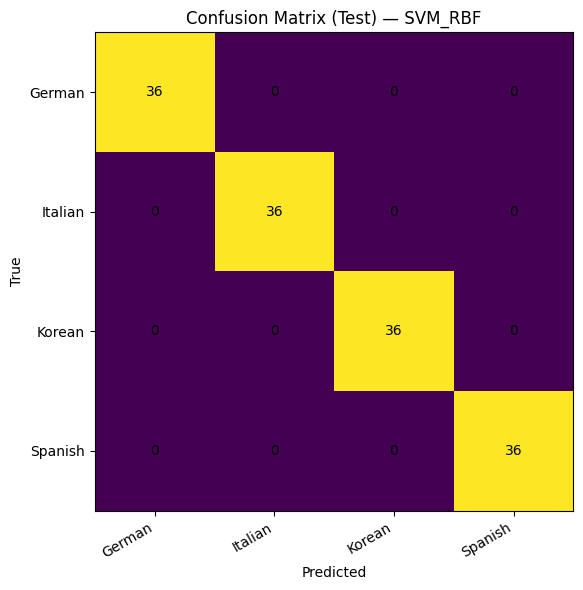

In [13]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(7, 6))
plt.imshow(cm)
plt.title(f"Confusion Matrix (Test) — {best_test_model_name}")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(range(len(classes)), classes, rotation=30, ha="right")
plt.yticks(range(len(classes)), classes)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]), ha="center", va="center")

plt.tight_layout()
plt.show()


## Save artifacts

We save:
- pipeline selection table
- per-model CV table (frozen pipeline)
- per-model test table
- best model as joblib


In [43]:

import numpy as np
import pandas as pd
import joblib
from pathlib import Path
from sklearn.metrics import confusion_matrix

ART = Path("artifacts")
ART.mkdir(exist_ok=True)


best_model = joblib.load(ART / "best_model_frozen_pipeline.joblib")


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

X = np.load(ART / "X.npy")
y_raw = np.load(ART / "y.npy", allow_pickle=True)

le = LabelEncoder()
y_enc = le.fit_transform(y_raw.astype(str))

RANDOM_STATE = 42

X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc,
    test_size=0.2,
    stratify=y_enc,
    random_state=RANDOM_STATE
)


y_pred = best_model.predict(X_test)


pred_df = pd.DataFrame({
    "true": le.inverse_transform(y_test),
    "pred": le.inverse_transform(y_pred),
    "true_encoded": y_test,
    "pred_encoded": y_pred
})

pred_df.to_csv(ART / "approach1_predictions_best_model.csv", index=False)


cm = confusion_matrix(y_test, y_pred)
np.save(ART / "approach1_confusion_matrix_best_model.npy", cm)

from sklearn.metrics import accuracy_score, f1_score

summary_df = pd.DataFrame([{
    "model": "BestModel_FrozenPipeline",
    "accuracy": accuracy_score(y_test, y_pred),
    "macro_f1": f1_score(y_test, y_pred, average="macro")
}])

summary_df.to_csv(ART / "approach1_results_summary.csv", index=False)


print("✅ Approach 1 evaluation artifacts saved:")
print(" - approach1_predictions_best_model.csv")
print(" - approach1_confusion_matrix_best_model.npy")
print(" - approach1_results_summary.csv")


✅ Approach 1 evaluation artifacts saved:
 - approach1_predictions_best_model.csv
 - approach1_confusion_matrix_best_model.npy
 - approach1_results_summary.csv


# Second approach: Train on Male, Test on Female (Gender split)

We evaluate domain shift across gender:
- Training set: all Male samples
- Test set: all Female samples

We train 4 classifiers:
- SVM
- Naive Bayes
- Logistic Regression
- Random Forest

Preprocessing:
- StandardScaler for SVM/LogReg (and safe for NB/RF too)
- Everything is done via sklearn Pipeline to avoid leakage in preprocessing.


In [15]:
import numpy as np
import pandas as pd

from pathlib import Path
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt

ARTIFACTS_DIR = Path("artifacts")

X = np.load(ARTIFACTS_DIR / "X.npy")
y = np.load(ARTIFACTS_DIR / "y.npy", allow_pickle=True)

le = LabelEncoder()
y_enc = le.fit_transform(y)
classes = list(le.classes_)

features_df = pd.read_csv(ARTIFACTS_DIR / "features.csv")

print("X:", X.shape, "y:", y_enc.shape, "features_df:", features_df.shape)
print(features_df["gender"].value_counts())


X: (720, 952) y: (720,) features_df: (720, 5)
gender
Female    360
Male      360
Name: count, dtype: int64


In [16]:
if "variant" in features_df.columns:
    features_clean = features_df[features_df["variant"] == "clean"].reset_index(drop=True)
else:
    features_clean = features_df.reset_index(drop=True)

X_clean = X[:len(features_clean)]
y_clean = y_enc[:len(features_clean)]

print("Using rows:", len(features_clean), "X_clean:", X_clean.shape)


Using rows: 720 X_clean: (720, 952)


In [17]:
g = features_clean["gender"].astype(str).str.lower().values

train_idx = np.where(g == "male")[0]
test_idx  = np.where(g == "female")[0]

X_train, y_train = X_clean[train_idx], y_clean[train_idx]
X_test,  y_test  = X_clean[test_idx],  y_clean[test_idx]

print("Train (Male):", X_train.shape, "Test (Female):", X_test.shape)
print("Train class counts:", np.bincount(y_train))
print("Test class counts:", np.bincount(y_test))


Train (Male): (360, 952) Test (Female): (360, 952)
Train class counts: [90 90 90 90]
Test class counts: [90 90 90 90]


## Train and evaluate the 4 classifiers (Male → Female)

Note:
- Scaling is applied inside the pipeline (no leakage issue here because scaling is fit only on training data).
- Random Forest doesn't require scaling, but keeping scaling makes pipelines consistent and does not harm.


In [18]:
models = {
    "SVM": Pipeline([("scaler", StandardScaler()),
                     ("clf", SVC(C=1, kernel="rbf", gamma="scale"))]),
    
    "NaiveBayes": Pipeline([("scaler", StandardScaler()),
                            ("clf", GaussianNB())]),
    
    "LogReg": Pipeline([("scaler", StandardScaler()),
                        ("clf", LogisticRegression(max_iter=5000))]),
    
    "RandomForest": Pipeline([("scaler", StandardScaler()),
                              ("clf", RandomForestClassifier(n_estimators=300, random_state=42))]),
}

rows = []
preds = {}

for name, pipe in models.items():
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    preds[name] = y_pred
    
    rows.append({
        "model": name,
        "accuracy": accuracy_score(y_test, y_pred),
        "macro_f1": f1_score(y_test, y_pred, average="macro")
    })

results_gender = pd.DataFrame(rows).sort_values("macro_f1", ascending=False).reset_index(drop=True)
results_gender


,model,accuracy,macro_f1
0,LogReg,0.683333,0.695070
1,SVM,0.575000,0.500554
2,RandomForest,0.469444,0.354152
3,NaiveBayes,0.275000,0.209655


## Detailed report for the best model (Male → Female)


In [19]:
best_name = results_gender.iloc[0]["model"]
best_pred = preds[best_name]

print("Best model:", best_name)
print("Accuracy:", accuracy_score(y_test, best_pred))
print("Macro-F1:", f1_score(y_test, best_pred, average="macro"))
print()
print(classification_report(y_test, best_pred, target_names=classes))


Best model: LogReg
Accuracy: 0.6833333333333333
Macro-F1: 0.6950697350875732

              precision    recall  f1-score   support

      German       0.45      0.89      0.60        90
     Italian       0.89      0.47      0.61        90
      Korean       0.86      0.74      0.80        90
     Spanish       0.98      0.63      0.77        90

    accuracy                           0.68       360
   macro avg       0.80      0.68      0.70       360
weighted avg       0.80      0.68      0.70       360



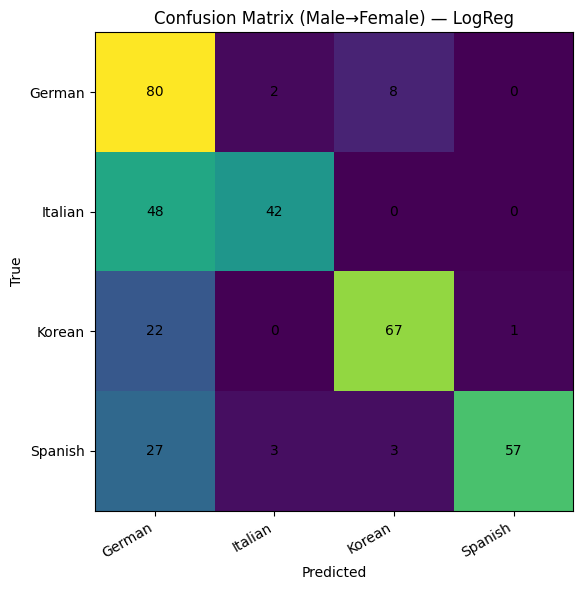

In [20]:
cm = confusion_matrix(y_test, best_pred)

fig = plt.figure(figsize=(7, 6))
plt.imshow(cm)
plt.title(f"Confusion Matrix (Male→Female) — {best_name}")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(range(len(classes)), classes, rotation=30, ha="right")
plt.yticks(range(len(classes)), classes)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]), ha="center", va="center")

plt.tight_layout()
plt.show()


## Save Gender Split Evaluation Results

We save:
- Model performance table (accuracy + macro F1)
- Per-sample predictions
- Confusion matrix (best model)


In [21]:
from pathlib import Path
import numpy as np
import pandas as pd
import joblib

SAVE_DIR = Path("artifacts")
SAVE_DIR.mkdir(exist_ok=True)


summary_path = SAVE_DIR / "gender_split_results_summary.csv"
results_gender.to_csv(summary_path, index=False)

print("Saved summary →", summary_path)



pred_df = pd.DataFrame({
    "true_label": le.inverse_transform(y_test),
    "true_label_encoded": y_test,
    "best_model_prediction": le.inverse_transform(best_pred),
    "best_model_prediction_encoded": best_pred
})

pred_path = SAVE_DIR / "gender_split_predictions_best_model.csv"
pred_df.to_csv(pred_path, index=False)

print("Saved predictions →", pred_path)


cm_path = SAVE_DIR / "gender_split_confusion_matrix_best_model.npy"
np.save(cm_path, cm)

print("Saved confusion matrix →", cm_path)



models_dir = SAVE_DIR / "gender_models"
models_dir.mkdir(exist_ok=True)

for name, model in models.items():
    model_path = models_dir / f"{name}_male_train_female_test.joblib"
    joblib.dump(model, model_path)

print("Saved trained models →", models_dir)


print("\n✅ Gender split evaluation artifacts saved successfully.")


Saved summary → artifacts/gender_split_results_summary.csv
Saved predictions → artifacts/gender_split_predictions_best_model.csv
Saved confusion matrix → artifacts/gender_split_confusion_matrix_best_model.npy
Saved trained models → artifacts/gender_models

✅ Gender split evaluation artifacts saved successfully.


# Third Approach — Gender Split + Augmented Training

Same as Approach 2:
- Train = Male
- Test = Female

Only difference:
- We augment ONLY the training (Male) audio
- Then retrain the same 4 classifiers
- Then evaluate on the same Female test set


In [35]:
import librosa
import numpy as np
from scipy.stats import skew, kurtosis
from tqdm import tqdm

SR = 16000
RNG = np.random.default_rng(42)

def safe_load_audio(path, sr=16000):
    try:
        y, sr = librosa.load(path, sr=sr, mono=True)
        return y, None
    except Exception as e:
        return None, str(e)

def clean_audio(y):
    try:
        y = y - np.mean(y)
        y = librosa.util.normalize(y)
        return y, None
    except:
        return None, "clean error"

def apply_random_augmentation(y):
    choice = RNG.integers(0, 4)

    if choice == 0:
        return y + RNG.normal(0, 0.005, len(y))

    if choice == 1:
        return librosa.effects.time_stretch(y, rate=RNG.uniform(0.9, 1.1))

    if choice == 2:
        return librosa.effects.pitch_shift(y, sr=SR, n_steps=RNG.uniform(-2, 2))

    if choice == 3:
        return y * RNG.uniform(0.8, 1.2)

    return y

def stats_vector(x):
    return np.array([
        np.mean(x), np.std(x), np.min(x), np.max(x),
        np.median(x), skew(x.flatten()), kurtosis(x.flatten())
    ])

def extract_feature_vector(y, sr):

    feats = []

    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=20)
    feats.append(np.hstack([stats_vector(mfcc[i]) for i in range(20)]))

    d1 = librosa.feature.delta(mfcc)
    feats.append(np.hstack([stats_vector(d1[i]) for i in range(20)]))

    d2 = librosa.feature.delta(mfcc, order=2)
    feats.append(np.hstack([stats_vector(d2[i]) for i in range(20)]))

    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=64)
    mel_db = librosa.power_to_db(mel)
    feats.append(np.hstack([stats_vector(mel_db[i]) for i in range(64)]))

    zcr = librosa.feature.zero_crossing_rate(y)
    feats.append(stats_vector(zcr))

    rms = librosa.feature.rms(y=y)
    feats.append(stats_vector(rms))

    cent = librosa.feature.spectral_centroid(y=y, sr=sr)
    feats.append(stats_vector(cent))

    bw = librosa.feature.spectral_bandwidth(y=y, sr=sr)
    feats.append(stats_vector(bw))

    roll = librosa.feature.spectral_rolloff(y=y, sr=sr)
    feats.append(stats_vector(roll))

    contrast = librosa.feature.spectral_contrast(y=y, sr=sr)
    feats.append(np.hstack([stats_vector(contrast[i]) for i in range(contrast.shape[0])]))

    feat = np.hstack(feats)

    return feat



In [39]:
AUG_COPIES_PER_FILE = 1

aug_X = []
aug_y = []

male_meta = features_clean.iloc[train_idx].reset_index(drop=True)

print("Augmenting Male Training Samples:", len(male_meta))

for _, row in tqdm(male_meta.iterrows(), total=len(male_meta)):

    src_path = row["clean_path"] if "clean_path" in row else row["path"]

    y_audio, err = safe_load_audio(src_path, sr=SR)
    if err is not None:
        continue

    y_audio, err = clean_audio(y_audio)
    if err is not None:
        continue

    for _ in range(AUG_COPIES_PER_FILE):

        y_aug = apply_random_augmentation(y_audio)
        feat = extract_feature_vector(y_aug, SR)
        feat = np.nan_to_num(feat, nan=0.0, posinf=0.0, neginf=0.0)


        aug_X.append(feat)
        aug_y.append(row["language"])

aug_X = np.array(aug_X)
aug_y = le.transform(np.array(aug_y))

print("Augmented Feature Shape:", aug_X.shape)


Augmenting Male Training Samples: 360


100%|██████████| 360/360 [03:25<00:00,  1.75it/s]

Augmented Feature Shape: (360, 952)


In [40]:
X_train_aug = np.vstack([X_train, aug_X])
y_train_aug = np.concatenate([y_train, aug_y])

print("Original Train:", X_train.shape)
print("Augmented Added:", aug_X.shape)
print("Final Train:", X_train_aug.shape)


Original Train: (360, 952)
Augmented Added: (360, 952)
Final Train: (720, 952)


In [41]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report

models_aug = {
    "SVM": Pipeline([("scaler", StandardScaler()), ("clf", SVC(C=1, kernel="rbf"))]),
    "NaiveBayes": Pipeline([("scaler", StandardScaler()), ("clf", GaussianNB())]),
    "LogReg": Pipeline([("scaler", StandardScaler()), ("clf", LogisticRegression(max_iter=5000))]),
    "RandomForest": Pipeline([("scaler", StandardScaler()), ("clf", RandomForestClassifier(n_estimators=300))]),
}

rows_aug = []
preds_aug = {}

for name, model in models_aug.items():

    model.fit(X_train_aug, y_train_aug)

    pred = model.predict(X_test)
    preds_aug[name] = pred

    rows_aug.append({
        "model": name,
        "accuracy": accuracy_score(y_test, pred),
        "macro_f1": f1_score(y_test, pred, average="macro")
    })

results_gender_aug = pd.DataFrame(rows_aug).sort_values("macro_f1", ascending=False).reset_index(drop=True)
results_gender_aug


,model,accuracy,macro_f1
0,LogReg,0.655556,0.655680
1,SVM,0.591667,0.508380
2,RandomForest,0.347222,0.316363
3,NaiveBayes,0.258333,0.182452


In [42]:
from pathlib import Path
import joblib

SAVE_DIR = Path("artifacts")
SAVE_DIR.mkdir(exist_ok=True)

results_gender_aug.to_csv(SAVE_DIR / "gender_split_augmented_results.csv", index=False)

best_name_aug = results_gender_aug.iloc[0]["model"]
best_pred_aug = preds_aug[best_name_aug]

pd.DataFrame({
    "true": le.inverse_transform(y_test),
    "pred": le.inverse_transform(best_pred_aug)
}).to_csv(SAVE_DIR / "gender_split_augmented_predictions.csv", index=False)

print("✅ Approach 3 results saved")


✅ Approach 3 results saved
